###Env to use: birdnet

In [1]:
import librosa
from skimage import feature
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import soundfile as sf
import os
from pathlib import Path
from sklearn.metrics import average_precision_score


In [2]:
from birdnetlib import Recording
from birdnetlib.analyzer import Analyzer
from datetime import datetime

# Load and initialize the BirdNET-Analyzer models.
analyzer = Analyzer()

c:\Users\dgnhk\anaconda3\envs\birdnet\lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)



Labels loaded.
load model True
Model loaded.
Labels loaded.
load_species_list_model
Meta model loaded.


Predict for positive segments first

In [3]:
output_folder='../data/Holderried/selections_wavs/'
wav_files = os.listdir(output_folder)

Predict for negative segments

In [4]:
output_folder='../data/train_data/audio/0/'
wav_files = os.listdir(output_folder)

In [10]:
# np.save('holderried_predictions.npy', predictions)
predictions = np.load('holderried_predictions.npy', allow_pickle=True)
predictions = predictions.item()

In [9]:
print(predictions.item())

{'10.wav': 0.9954662322998047, '1000.wav': 0.9922845363616943, '1001.wav': 0.9887539148330688, '1002.wav': 0.0, '1003.wav': 0.3924953043460846, '1004.wav': 0.9733524918556213, '1005.wav': 0.9461320042610168, '1006.wav': 0.11231496185064316, '1007.wav': 0.0, '1008.wav': 0.0, '1010.wav': 0.28477945923805237, '1011.wav': 0.9979021549224854, '1012.wav': 0.6563695669174194, '1013.wav': 0.8411304354667664, '1014.wav': 0.9982848763465881, '1017.wav': 0.6688101291656494, '1018.wav': 0.9881882071495056, '1019.wav': 0.6249352097511292, '1020.wav': 0.9982781410217285, '1021.wav': 0.052715614438056946, '1022.wav': 0.9995335340499878, '1023.wav': 0.9962621331214905, '1024.wav': 0.9889667630195618, '1025.wav': 0.969664454460144, '1027.wav': 0.7030919194221497, '1028.wav': 0.9964268803596497, '1029.wav': 0.9922608733177185, '1030.wav': 0.0, '1031.wav': 0.9691020250320435, '1032.wav': 0.9762029051780701, '1033.wav': 0.991881787776947, '1034.wav': 0.04755405709147453, '1098.wav': 0.39771750569343567, '

In [11]:
sorted_keys = sorted(predictions.keys())

# Step 2: Extract scores and generate true labels
y_pred = [predictions[k] for k in sorted_keys]
y_true = [0 if len(k)>9 else 1 for k in sorted_keys]

# Step 3: Compute Average Precision
ap = average_precision_score(y_true, y_pred)
ap

0.8945547437215977

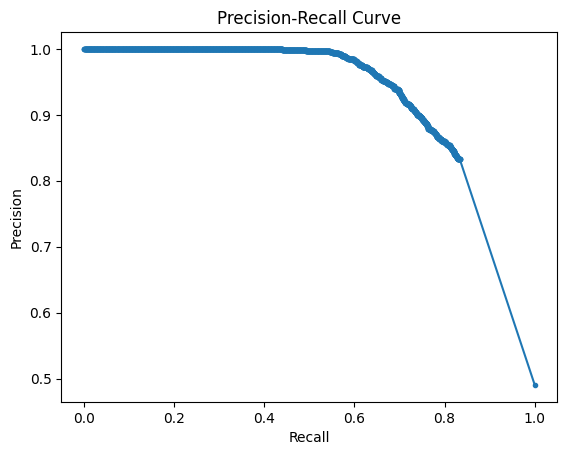

In [14]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Only for binary classification (adjust for multi-class)
precision, recall, thr = precision_recall_curve(y_true, y_pred)

plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


Text(0.5, 0, 'Threshold')

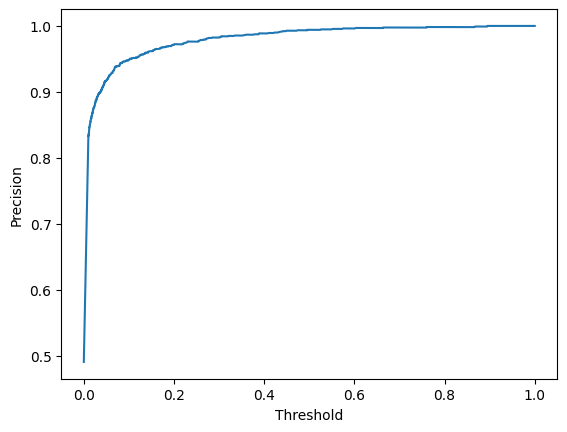

In [15]:
plt.plot(thr,precision[:-1])
plt.ylabel("Precision")
plt.xlabel("Threshold")

Text(0.5, 0, 'Threshold')

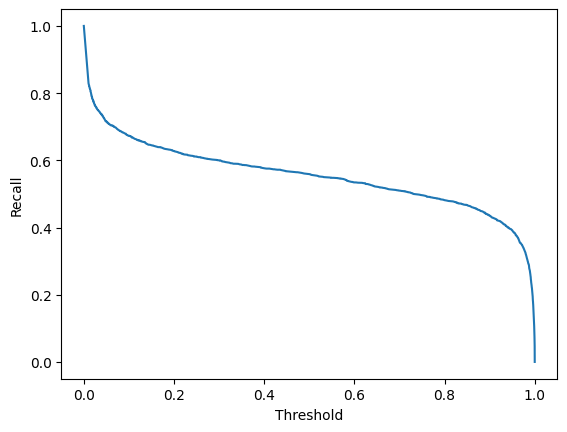

In [16]:
plt.plot(thr, recall[:-1])
plt.ylabel("Recall")
plt.xlabel("Threshold")

In [14]:
#preds_negative = {k: predictions[k] for k in wav_files if k in predictions}
#preds_negative = np.array(list(preds_negative.values()))

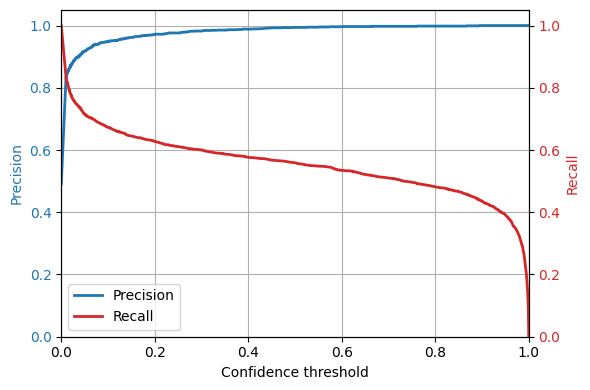

In [22]:
import matplotlib.pyplot as plt

# Sample data
x = thr
y1 = precision[:-1]
y2 = recall[:-1]

# Create figure and first axis
fig, ax1 = plt.subplots(figsize=(6, 4))

# Precision curve
color1 = 'tab:blue'
line1 = ax1.plot(
    x, y1,
    color=color1,
    linewidth=2,
    label='Precision'
)

ax1.set_xlabel('Confidence threshold')
ax1.set_ylabel('Precision', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.05])
ax1.grid(True)

# Second y-axis for Recall
ax2 = ax1.twinx()

color2 = 'tab:red'
line2 = ax2.plot(
    x, y2,
    color=color2,
    linewidth=2,
    label='Recall'
)

ax2.set_ylabel('Recall', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim([0, 1.05])

# Combined legend
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='best')

# Improve layout
fig.tight_layout()

# Save figures
fig.savefig(
    "precision_recall_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "precision_recall_threshold.tiff",
    dpi=600,
    bbox_inches="tight"
)

#fig.savefig("precision_recall_threshold.pdf", bbox_inches="tight")

plt.show()

In [21]:
f1 = 2*precision*recall/(precision+recall)

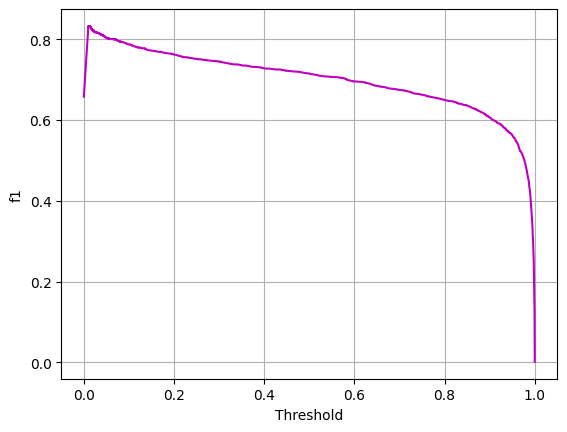

In [23]:
plt.plot(thr, f1[:-1], '-m')
plt.ylabel("f1")
plt.xlabel("Threshold")
plt.grid()

In [24]:
np.max(f1)

0.8333679186553228

Map the values to uniformly spaced threshold values

In [25]:
from scipy.interpolate import interp1d

In [26]:
#thr_uniform = np.linspace(0, 1, 101)
thr_uniform = np.linspace(thr.min(), thr.max(), 100)

In [27]:
interpolator = interp1d(thr, f1[:-1], kind='linear')  # or 'cubic', 'quadratic', etc.
f1_score = interpolator(thr_uniform)

In [28]:
np.savez('holderried_f1.npz', thr=thr_uniform, f1=f1_score)

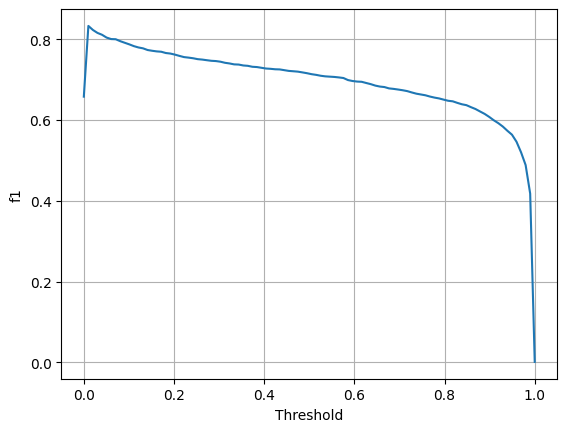

In [29]:
plt.plot(thr_uniform,f1_score)
plt.ylabel("f1")
plt.xlabel("Threshold")
plt.grid()